## Section 0 - Dependencies
Install the required libraries. **The Gemma 4 cell takes 2-3 minutes** to install.


In [1]:
!nvidia-smi

Sat May 30 13:41:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P0             43W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# Install vision and tracking libraries
!pip install -q ultralytics supervision opencv-python-headless pillow scikit-learn matplotlib gradio
print('OK vision/tracking')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.3 MB/s eta 0:00:00
OK vision/tracking


In [3]:
%%capture
# Install Unsloth and Gemma 4 (takes 2-3 min)
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"
!pip install --no-deps transformers==5.5.0 "tokenizers>=0.22.0,<=0.23.0"
!pip install --no-deps --upgrade timm

In [4]:
import torch
torch._dynamo.config.recompile_limit = 64
print('OK - dependencies for Gemma 4')

OK - dependencies for Gemma 4


## Section 1 - Imports and global constants


In [5]:
import os, json, time, random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, deque, Counter
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

import cv2
import supervision as sv
from ultralytics import YOLO

SEED = 29348
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

# File paths - adjust VIDEO_PATH if your file has a different name
VIDEO_PATH       = '/content/video.mp4'
CNN_WEIGHTS      = 'best_cnn_classifier.pth'
LSTM_WEIGHTS     = 'best_lstm_tracker.pth'
BALL_WEIGHTS = 'volleyball_ball_best.pt'   # YOLO custom entrenado para el balon
PERSONS_WEIGHTS = 'volleyball_persons_best.pt'   # YOLO custom entrenado para personas

# YOLO COCO class indices
YOLO_PERSON_CLASS = 0    # person
YOLO_BALL_CLASS   = 32   # sports ball

# CNN role classes - must match the trained best_cnn_classifier.pth
ACTION_CLASSES = ['attacker','receiver','refree','server','setter']
NUM_ACTION_CLASSES = len(ACTION_CLASSES)
IDX_TO_ACTION = {i: c for i, c in enumerate(sorted(ACTION_CLASSES))}

# BGR colors for drawing bounding boxes
CLASS_COLORS_BGR = {
    'volleyball':(255,255,255),'attacker':(0,69,255),'receiver':(209,206,0),
    'refree':(0,215,255),'server':(180,105,255),'setter':(0,252,124),
    'team_1':(255,100,0),'team_2':(0,200,100),'ball':(0,255,255),
}
BALL_COLOR_BGR = (0, 255, 255)
print(f'IDX_TO_ACTION: {IDX_TO_ACTION}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dispositivo: cuda
   GPU: NVIDIA A100-SXM4-40GB
IDX_TO_ACTION: {0: 'attacker', 1: 'receiver', 2: 'refree', 3: 'server', 4: 'setter'}


## Section 2 - Neural network architectures
We define the **4 PyTorch architectures** used in the system:
- `VolleyballCNN`: CNN that classifies the role of each detected player (Val Acc: 93.6%)
- `TrajectoryLSTM`: Bidirectional LSTM that predicts player movement trajectories (Val MSE: 0.001)
- `TeamMLP`: MLP trained with K-means labels to classify players by shirt color


In [6]:
# CNN role classifier - compatible with best_cnn_classifier.pth
class VolleyballCNN(nn.Module):
    '''
    Custom CNN: 4 blocks of Conv+BN+ReLU+MaxPool + FC head with Dropout.
    Classifies the player role: attacker, receiver, refree, server, setter.
    Trained on volley_detection v5. Val Acc: 93.6%.
    '''
    def __init__(self, num_classes=5, dropout_p=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),  nn.BatchNorm2d(32),  nn.ReLU(True), nn.MaxPool2d(2,2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64),  nn.ReLU(True), nn.MaxPool2d(2,2),
            nn.Conv2d(64,128,3,padding=1),nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2,2),
            nn.Conv2d(128,256,3,padding=1),nn.BatchNorm2d(256),nn.ReLU(True), nn.MaxPool2d(2,2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.Linear(256,128), nn.ReLU(True),
            nn.Dropout(dropout_p), nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Trajectory LSTM - compatible with best_lstm_tracker.pth
class TrajectoryLSTM(nn.Module):
    '''
    Bidirectional LSTM with 2 layers for trajectory prediction.
    Input:  (batch, seq=20, 5) - x, y, vx, vy, conf per frame
    Output: (batch, pred=10, 2) - future (x, y) positions
    Val MSE: 0.001
    '''
    def __init__(self, input_size=5, hidden_size=128, num_layers=2, pred_len=10, dropout=0.3):
        super().__init__()
        self.pred_len = pred_len
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,
                            dropout=dropout if num_layers>1 else 0, bidirectional=True)
        self.predictor = nn.Sequential(
            nn.Linear(hidden_size*2, 64), nn.ReLU(True),
            nn.Dropout(dropout), nn.Linear(64, pred_len*2)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.predictor(out[:, -1, :]).view(-1, self.pred_len, 2)

print('Architectures defined: VolleyballCNN, TrajectoryLSTM')

Architectures defined: VolleyballCNN, TrajectoryLSTM


In [7]:
# MLP for team classification by shirt color
TEAM_CLASSES = ['team_1', 'team_2', 'refree']
TEAM_MLP_WEIGHTS = 'best_team_mlp.pt'

class TeamMLP(nn.Module):
    """
    MLP that classifies a player's team from the HSV color histogram of their torso.
    Architecture: 16 features -> 32 -> 16 -> 3 classes (team_1, team_2, refree)
    """
    def __init__(self, input_size=16, num_classes=3, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(True),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.ReLU(True),
            nn.Dropout(dropout),
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        return self.net(x)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print(f'TeamMLP defined ({len(TEAM_CLASSES)} classes: {TEAM_CLASSES})')

TeamMLP defined (3 classes: ['team_1', 'team_2', 'refree'])


## Section 3 - Homography, 2D minimap, and camera motion estimator
Calibrates the pixel-to-minimap coordinate transform (450x300 canvas). The net is at X=225, field corners at (50,38)-(400,263).
The `CameraMotionEstimator` uses ORB+RANSAC on the upper part of the frame (stands) to dynamically correct the homography when the camera moves.


In [8]:
# Homography matrix - 10 point RANSAC calibration, reprojection error <8px
# Manually calibrated on the reference frame (FRA vs JPN match).
# When the camera moves, use CameraMotionEstimator for dynamic correction.
# dst coordinates are absolute canvas pixels (450x300 canvas)
# Court: (50,38)-(400,263) | Net: x=225 | Attack lines: x=167, x=283
_src = np.float32([
    [ 529, 653],   # 1. Esquina arriba-izquierda
    [1580, 677],   # 2. Esquina arriba-derecha
    [1756, 883],   # 3. Esquina abajo-derecha
    [ 359, 844],   # 4. Esquina abajo-izquierda
    [1052, 666],   # 5. Red toca línea superior
    [1048, 863],   # 6. Red toca línea inferior
    [ 877, 659],   # 7. Línea ataque izq. arriba
    [ 816, 857],   # 8. Línea ataque izq. abajo
    [1226, 669],   # 9. Línea ataque der. arriba
    [1283, 871],   # 10. Línea ataque der. abajo
])
_dst = np.float32([
    [ 50, 38], [400, 38], [400, 263], [ 50, 263],
    [225, 38], [225, 263],
    [167, 38], [167, 263],
    [283, 38], [283, 263],
])
H_MATRIX, _ = cv2.findHomography(_src, _dst, cv2.RANSAC, 5.0)
print('Homography calibrated (RANSAC, 10 points, error <8px)')

# Field polygon - slightly larger than the court to filter out-of-court detections
FIELD_POLYGON = np.array([
    [ 100, 530],
    [1860, 530],
    [1860, 950],
    [  60, 950],
], dtype=np.int32)

# Referee zones - players whose feet land here are automatically labelled as referee
REFEREE_ZONES = [
    (450, 540,  750, 660),   # upper referee (high chair)
    (920, 845, 1090, 990),   # lower referee (behind the net)
]
print('FIELD_POLYGON and REFEREE_ZONES ready')

Homography calibrated (RANSAC, 10 points, error <8px)
FIELD_POLYGON and REFEREE_ZONES ready


In [9]:
# draw_minimap: renders the 2D top-view court with players and ball
def draw_minimap(positions, H_matrix, frame_w=1920, frame_h=1080,
                 map_w=450, map_h=300, ball_pos=None):
    '''
    Minimap 2D top-view alineado exactamente con H_matrix (450x300 absoluto).
    Para incrustar a otro tamaño: renderizar a 450x300 y luego cv2.resize.
    Usa el pie del jugador (foot_y) para mayor precisión.
    '''
    mm = np.zeros((map_h,map_w,3),dtype=np.uint8)
    mm[:,:] = (180,210,180)
    cv2.rectangle(mm,(50,38),(400,263),(34,100,34),-1)
    cv2.rectangle(mm,(50,38),(400,263),(255,255,255),2)
    cv2.line(mm,(225,38),(225,263),(255,255,255),3)
    cv2.line(mm,(167,38),(167,263),(200,200,200),1)
    cv2.line(mm,(283,38),(283,263),(200,200,200),1)
    cv2.rectangle(mm,(1,1),(map_w-1,map_h-1),(100,100,100),1)
    cv2.putText(mm,'MINIMAP',(map_w//2-22,map_h-4),cv2.FONT_HERSHEY_SIMPLEX,.28,(50,50,50),1)
    for pos in positions:
        try:
            foot_x = pos['cx']*frame_w
            foot_y = pos.get('foot_y',pos['cy'])*frame_h
            pm = cv2.perspectiveTransform(
                np.float32([[foot_x,foot_y]]).reshape(1,1,2),H_matrix).reshape(2)
            px,py = int(pm[0]),int(pm[1])
            if 2<px<map_w-2 and 2<py<map_h-2:
                c=CLASS_COLORS_BGR.get(pos.get('class_name','team_1'),(200,200,200))
                cv2.circle(mm,(px,py),6,c,-1); cv2.circle(mm,(px,py),6,(0,0,0),1)
                cv2.putText(mm,str(pos.get('track_id','')),(px+7,py+3),
                            cv2.FONT_HERSHEY_SIMPLEX,.28,(0,0,0),1)
        except: pass
    if ball_pos is not None:
        try:
            pm = cv2.perspectiveTransform(
                np.float32([[ball_pos[0]*frame_w,ball_pos[1]*frame_h]]).reshape(1,1,2),
                H_matrix).reshape(2)
            bx,by = int(pm[0]),int(pm[1])
            if 2<bx<map_w-2 and 2<by<map_h-2:
                cv2.circle(mm,(bx,by),7,(0,255,255),-1)
                cv2.circle(mm,(bx,by),7,(0,0,0),2)
                cv2.putText(mm,'B',(bx+8,by+3),cv2.FONT_HERSHEY_SIMPLEX,.3,(0,0,0),1)
        except: pass
    return mm

print('draw_minimap and CameraMotionEstimator ready')


# -- CameraMotionEstimator: corrige homografía cuando la cámara se mueve --
# Estimamos la homografía que alinea el fondo (gradas, paneles) del frame
# actual con el frame de referencia y componemos:
#       H_dyn = H_static @ M_motion^-1
class CameraMotionEstimator:
    '''
    ORB + RANSAC applied to the upper portion of the frame (background_top_ratio)
    to avoid matching features on moving players.
    '''
    def __init__(self, reference_frame_bgr, h_static, n_features=2000,
                 background_top_ratio=0.55, min_matches=20):
        self.h_static = h_static.astype(np.float64)
        self.orb = cv2.ORB_create(nfeatures=n_features)
        self.bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
        self.min_matches = min_matches
        gray = cv2.cvtColor(reference_frame_bgr, cv2.COLOR_BGR2GRAY)
        h, w = gray.shape
        self.mask = np.zeros((h, w), dtype=np.uint8)
        self.mask[:int(h*background_top_ratio), :] = 255
        self.kp_ref, self.des_ref = self.orb.detectAndCompute(gray, self.mask)
        if self.des_ref is None or len(self.kp_ref) < min_matches:
            raise RuntimeError('Pocas features en el frame de referencia')

    def estimate_motion(self, frame_bgr):
        gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
        kp, des = self.orb.detectAndCompute(gray, self.mask)
        if des is None or len(kp) < self.min_matches:
            return np.eye(3), 0
        matches = self.bf.match(self.des_ref, des)
        matches = sorted(matches, key=lambda m: m.distance)[:500]
        if len(matches) < self.min_matches:
            return np.eye(3), len(matches)
        src = np.float32([self.kp_ref[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
        dst = np.float32([kp[m.trainIdx].pt for m in matches]).reshape(-1,1,2)
        M, inliers = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
        if M is None:
            return np.eye(3), 0
        return M.astype(np.float64), int(inliers.sum()) if inliers is not None else 0

    def homography_for(self, frame_bgr):
        '''Returns (H_dyn, M_motion, n_inliers). H_dyn = H_static @ M^-1.'''
        M, n = self.estimate_motion(frame_bgr)
        try:
            M_inv = np.linalg.inv(M)
        except np.linalg.LinAlgError:
            M_inv = np.eye(3)
        return self.h_static @ M_inv, M, n

print('CameraMotionEstimator defined')

draw_minimap and CameraMotionEstimator ready
CameraMotionEstimator defined


In [10]:
# Polygonal ROI for the court and team classification function.
# Calibrated on the reference frame. When the camera moves, the polygon
# is warped using M_motion from CameraMotionEstimator (see process_frame).
FIELD_POLYGON = np.array([
    [290,  620],
    [1830, 640],
    [1900, 960],
    [200,  940],
], dtype=np.int32)

def is_inside_field(cx_px, bottom_y_px, polygon=None):
    '''Returns True if the player foot position is inside the court polygon.'''
    if polygon is None: polygon = FIELD_POLYGON
    res = cv2.pointPolygonTest(
        polygon.astype(np.float32),(float(cx_px),float(bottom_y_px)),False)
    return res >= 0

def classify_player_team(cx_px, bottom_y_px, crop_bgr, H_matrix=None):
    '''
    Classifies a player's team using two criteria:
    1. Dark shirt color (V<70 in HSV) -> referee
    2. Homography projection -> team_1 (X<225) or team_2 (X>=225)
    The net at X=225 is invariant to camera motion only when the dynamic
    H_matrix (H_static @ M_motion^-1) is passed in.
    '''
    if H_matrix is None: H_matrix = H_MATRIX
    h = crop_bgr.shape[0]
    shirt = crop_bgr[:max(1,h//3),:]
    if shirt.size==0: return 'team_1'
    hsv = cv2.cvtColor(shirt,cv2.COLOR_BGR2HSV)
    if hsv[:,:,2].mean() < 70: return 'refree'
    try:
        pm = cv2.perspectiveTransform(
            np.float32([[cx_px,bottom_y_px]]).reshape(1,1,2),H_matrix).reshape(2)
        return 'team_1' if pm[0] < 225 else 'team_2'
    except:
        return 'team_1' if cx_px < 960 else 'team_2'

print('Court ROI and team classifier ready')

Court ROI and team classifier ready


## Section 4 - YOLO detection function
Wrapper around `yolo_detect` that calls our custom YOLO model and returns detected players and the ball as lists of dicts.


In [11]:
def yolo_detect(image_bgr, yolo_model, person_conf=0.35, ball_conf=0.15,
                min_person_height=60):
    '''
    Detects players and ball in a BGR frame using YOLO.
    Returns (players, balls) as lists of dicts with box, score, class_name.
    '''
    results = yolo_model.predict(image_bgr, conf=min(person_conf, ball_conf),
                                  verbose=False, device=DEVICE)[0]
    players, balls = [], []
    if results.boxes is None:
        return players, balls
    for box in results.boxes:
        cls = int(box.cls[0])
        score = float(box.conf[0])
        x1, y1, x2, y2 = [float(v) for v in box.xyxy[0].cpu().numpy()]
        if cls == YOLO_PERSON_CLASS and score >= person_conf:
            if (y2 - y1) < min_person_height: continue
            players.append({
                'box': np.array([x1, y1, x2, y2]),
                'score': score, 'class_name': 'player'
            })
        elif cls == YOLO_BALL_CLASS and score >= ball_conf:
            balls.append({
                'box': np.array([x1, y1, x2, y2]),
                'score': score, 'class_name': 'volleyball'
            })
    # Keep only the highest-confidence ball detection
    if balls:
        balls.sort(key=lambda d: -d['score'])
        balls = balls[:1]
    return players, balls

print('yolo_detect ready')

yolo_detect ready


## Section 5 - BallTracker
Wrapper around our custom YOLO ball model. Keeps a 40-frame buffer with a fade effect and discards impossible jumps between consecutive frames.


In [12]:
class BallTracker:
    '''
    Ball tracker using our custom YOLO model trained on match frames.
    Keeps a 40-frame trajectory buffer with a fade effect.
    Discards detections that jump too far between consecutive frames.
    '''
    def __init__(self, yolo_model, ball_conf=0.15, max_missing=15):
        self.yolo = yolo_model
        self.ball_conf = ball_conf
        self.trajectory = deque(maxlen=40)
        self.missing = 0
        self.max_missing = max_missing
        self.last_pos = None

    def detect(self, frame_bgr):
        H_f, W_f = frame_bgr.shape[:2]
        results = self.yolo.predict(frame_bgr, conf=self.ball_conf,
                                     verbose=False, device=DEVICE)[0]
        if results.boxes is None or len(results.boxes) == 0:
            self.missing += 1
            if self.missing > self.max_missing: self.last_pos = None
            return None
        candidates = []
        for box in results.boxes:
            score = float(box.conf[0])
            x1, y1, x2, y2 = [float(v) for v in box.xyxy[0].cpu().numpy()]
            cx, cy = (x1+x2)/2, (y1+y2)/2
            w_b, h_b = x2-x1, y2-y1
            if w_b > 100 or h_b > 100: continue
            if w_b < 3 or h_b < 3: continue
            bonus = 0.0
            if self.last_pos:
                dist = ((cx-self.last_pos[0])**2 + (cy-self.last_pos[1])**2)**0.5
                if dist > 350: continue
                bonus = max(0.0, 0.3 - dist/1000)
            candidates.append({
                'box': np.array([x1,y1,x2,y2]),
                'cx': cx, 'cy': cy, 'cx_n': cx/W_f, 'cy_n': cy/H_f,
                'score': score + bonus, 'conf': score, 'class_name': 'volleyball'
            })
        if candidates:
            best = max(candidates, key=lambda x: x['score'])
            self.last_pos = (best['cx'], best['cy'])
            self.trajectory.append((best['cx_n'], best['cy_n']))
            self.missing = 0
            return best
        self.missing += 1
        if self.missing > self.max_missing: self.last_pos = None
        return None

    def draw_trajectory(self, frame):
        pts = list(self.trajectory); H_f, W_f = frame.shape[:2]
        for i in range(1, len(pts)):
            alpha = i/len(pts)
            color = (0, int(255*alpha), int(255*alpha))
            p1 = (int(pts[i-1][0]*W_f), int(pts[i-1][1]*H_f))
            p2 = (int(pts[i][0]*W_f), int(pts[i][1]*H_f))
            cv2.line(frame, p1, p2, color, max(1, int(4*alpha)))
        if pts:
            cx, cy = int(pts[-1][0]*W_f), int(pts[-1][1]*H_f)
            cv2.circle(frame, (cx,cy), 14, (0,255,255), 3)
            cv2.circle(frame, (cx,cy), 5, (255,255,255), -1)
            cv2.putText(frame, 'BALL', (cx+16, cy+5),
                        cv2.FONT_HERSHEY_SIMPLEX, .5, (0,255,255), 2)
        return frame

    def reset(self):
        self.trajectory.clear(); self.last_pos = None; self.missing = 0

print('BallTracker defined (uses custom YOLO ball model)')

BallTracker defined (uses custom YOLO ball model)


## Section 6 - Torso color feature extractor
Helper function that crops the torso region of a detected player (upper-center of the bounding box) and computes a 16-bin HSV histogram. This vector is the input to the `TeamMLP`.


In [13]:
# Extract torso color features as an HSV histogram
def extract_torso_color_features(frame_bgr, bbox):
    """
    Extracts an HSV histogram from the player torso region.
    bbox: (x1, y1, x2, y2) in pixels.
    Returns: normalized 16-feature vector (8 H bins + 8 S bins).
    """
    x1, y1, x2, y2 = [int(v) for v in bbox]
    w = x2 - x1
    h = y2 - y1

    torso_x1 = x1 + int(w * 0.25)
    torso_x2 = x1 + int(w * 0.75)
    torso_y1 = y1 + int(h * 0.20)
    torso_y2 = y1 + int(h * 0.55)

    H_f, W_f = frame_bgr.shape[:2]
    torso_x1 = max(0, torso_x1)
    torso_x2 = min(W_f, torso_x2)
    torso_y1 = max(0, torso_y1)
    torso_y2 = min(H_f, torso_y2)

    crop = frame_bgr[torso_y1:torso_y2, torso_x1:torso_x2]
    if crop.size == 0 or crop.shape[0] < 5 or crop.shape[1] < 5:
        return None

    hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
    hist_h = cv2.calcHist([hsv], [0], None, [8], [0, 180])
    hist_s = cv2.calcHist([hsv], [1], None, [8], [0, 256])

    features = np.concatenate([hist_h.flatten(), hist_s.flatten()])
    total = features.sum()
    if total > 0:
        features = features / total
    return features.astype(np.float32)

print('extract_torso_color_features ready')

extract_torso_color_features ready


## Section 7 - Gemma 4 (Vision Language Model)
Loads the **Gemma 4** multimodal Transformer via Unsloth (`unsloth/gemma-4-E2B-it`).
- `describe_scene(image, detections)`: automatic caption with detection context
- `answer_question(image, question)`: free-form VQA

Set `USE_GEMMA = False` if you run out of VRAM.


In [14]:
# Load Gemma 4 via Unsloth
# If you run out of VRAM or want to skip the VLM, set USE_GEMMA = False.
USE_GEMMA = True   # cambia a False para saltar el VLM
GEMMA_MODEL_NAME = 'unsloth/gemma-4-E2B-it'

if USE_GEMMA:
    try:
        from unsloth import FastModel
        from transformers import TextStreamer
        print(f'Cargando {GEMMA_MODEL_NAME}...')
        gemma_model, gemma_tokenizer = FastModel.from_pretrained(
            model_name = GEMMA_MODEL_NAME,
            dtype = None,
            max_seq_length = 1024,
            load_in_4bit = False,
            full_finetuning = False,
        )
        print('Gemma 4 loaded')
    except Exception as e:
        print(f'No se pudo cargar Gemma: {e}')
        gemma_model, gemma_tokenizer = None, None
else:
    gemma_model, gemma_tokenizer = None, None
    print('Gemma 4 desactivado (USE_GEMMA=False)')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
Cargando unsloth/gemma-4-E2B-it...
==((====))==  Unsloth 2026.5.8: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


model.safetensors:   0%|          | 0.00/10.2G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/1.69k [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/16.8k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/19.9k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

Gemma 4 loaded


In [15]:
class VolleyballGemmaAssistant:
    '''
    Gemma 4 wrapper integrated with the pipeline.
    - describe_scene(image_pil, detections): automatic scene caption
    - answer_question(image_pil, question): basic VQA
    - answer_question_with_context(image_pil, question, pipeline):
        full VQA with structured detection context (recommended)
    '''
    def __init__(self, model, tokenizer, max_new_tokens=60):
        self.model = model
        self.tokenizer = tokenizer
        self.max_new_tokens = max_new_tokens
        self.enabled = (model is not None) and (tokenizer is not None)
        if self.enabled:
            print('VolleyballGemmaAssistant ready')
        else:
            print('VolleyballGemmaAssistant disabled (Gemma not loaded)')

    def _generate(self, messages, max_new_tokens=None):
        if not self.enabled: return ''
        mnt = max_new_tokens or self.max_new_tokens
        try:
            inputs = self.tokenizer.apply_chat_template(
                messages, add_generation_prompt=True,
                tokenize=True, return_dict=True, return_tensors='pt'
            ).to('cuda' if DEVICE.type=='cuda' else 'cpu')
            input_len = inputs['input_ids'].shape[1]
            with torch.no_grad():
                out = self.model.generate(
                    **inputs, max_new_tokens=mnt,
                    temperature=1.0, top_p=0.95, top_k=64,
                    do_sample=True,
                )
            gen = out[0, input_len:]
            text = self.tokenizer.decode(gen, skip_special_tokens=True)
            return ' '.join(text.split())[:400]
        except Exception as e:
            return f'(VLM error: {str(e)[:60]})'

    def describe_scene(self, image_pil, detections):
        counts = Counter(d.get('team', '?') for d in detections)
        ctx = (f"There are {counts.get('team_1',0)} players in team 1, "
               f"{counts.get('team_2',0)} in team 2, "
               f"{counts.get('refree',0)} referees.")
        messages = [{
            'role': 'user',
            'content': [
                {'type': 'image', 'image': image_pil},
                {'type': 'text',
                 'text': f'This is a volleyball match. {ctx} '
                         f'Describe the current action in one short sentence.'}
            ]
        }]
        return self._generate(messages, max_new_tokens=60)

    def answer_question(self, image_pil, question):
        '''Basic VQA without pipeline context (legacy method).'''
        messages = [{
            'role': 'user',
            'content': [
                {'type': 'image', 'image': image_pil},
                {'type': 'text', 'text': question}
            ]
        }]
        return self._generate(messages, max_new_tokens=200)

    def answer_question_with_context(self, image_pil, question, pipeline):
        '''
        Full VQA: processes the image with the pipeline, builds structured
        context from the detections, and sends it to Gemma together with
        the annotated image and the user question.
        '''
        # 1. Run the full pipeline on the image to get detections
        frame_bgr = cv2.cvtColor(np.array(image_pil), cv2.COLOR_RGB2BGR)
        pipeline.reset()
        annotated_bgr, info = pipeline.process_frame(frame_bgr)

        # 2. Build structured context from the detections
        teams = Counter(d['team'] for d in info['detections'])
        ball = info['ball']
        n_total = len(info['detections'])

        ctx_lines = [
            f"=== AUTOMATED VISION SYSTEM ANALYSIS ===",
            f"Sport: volleyball",
            f"Total players detected: {n_total}",
            f"  - Team 1: {teams.get('team_1', 0)} players",
            f"  - Team 2: {teams.get('team_2', 0)} players",
            f"  - Referees: {teams.get('refree', 0)}",
        ]
        if ball:
            ctx_lines.append(
                f"Ball: detected at normalized position "
                f"(x={ball['cx_n']:.2f}, y={ball['cy_n']:.2f}), confidence={ball['conf']:.2f}"
            )
        else:
            ctx_lines.append("Ball: not detected in this frame")

        # Add per-player details (capped at 8 to keep the prompt short)
        if info['detections']:
            ctx_lines.append("Player breakdown:")
            for d in info['detections'][:8]:
                side = 'LEFT' if d['cx'] < 0.5 else 'RIGHT'
                ctx_lines.append(
                    f"  - Player #{d['track_id']}: team={d['team']}, "
                    f"role={d['role']}, side={side}"
                )

        context = '\n'.join(ctx_lines)

        # 3. Build the enriched prompt
        full_prompt = (
            f"{context}\n\n"
            f"=== USER QUESTION ===\n"
            f"{question}\n\n"
            f"Answer the question using BOTH the annotated image (with bounding "
            f"boxes and labels) AND the system analysis above. Be concise and specific."
        )

        # 4. Convert annotated frame to PIL and send to Gemma
        annotated_pil = Image.fromarray(cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB))

        messages = [{
            'role': 'user',
            'content': [
                {'type': 'image', 'image': annotated_pil},
                {'type': 'text', 'text': full_prompt}
            ]
        }]
        return self._generate(messages, max_new_tokens=250)

print('VolleyballGemmaAssistant clase definida (con contexto integrado)')

VolleyballGemmaAssistant clase definida (con contexto integrado)


## Section 8 - Integrated pipeline
The `VolleyballPipeline` class connects all modules in order:
1. **YOLO** detects players in the frame
2. **CameraMotionEstimator** corrects H_MATRIX and FIELD_POLYGON per frame
3. **Polygonal ROI filter** removes detections outside the court (stands, bench)
4. **ByteTrack** assigns persistent IDs across frames
5. **classify_player_team** uses the homography to assign team (net at X=225)
6. **CNN** classifies the role of each player crop by crop
7. **LSTM** predicts future player trajectories (arrow overlay)
8. **BallTracker** maintains a 40-frame ball trajectory buffer
9. **Gemma 4** describes the scene every 60 frames
10. **Minimap 2D** is rendered and embedded in the bottom-right corner


In [16]:
class VolleyballPipeline:
    '''
    End-to-end pipeline (YOLO + minimap + Gemma):
    1. YOLO detects players in a single forward pass
    2. CameraMotionEstimator corrects H_MATRIX and FIELD_POLYGON per frame
    3. Dynamic polygonal ROI filter removes detections outside the court
    4. ByteTrack assigns persistent IDs across frames
    5. classify_player_team uses homography to assign team (net at X=225)
    6. CNN classifies each player crop role
    7. LSTM predicts future player trajectories
    8. BallTracker maintains a 40-frame ball buffer
    9. Gemma 4 describes the scene every 60 frames
    10. 2D minimap is embedded in the bottom-right corner
    '''
    def __init__(self, yolo_model, cnn, lstm, ball_tracker,
                 vlm=None, player_conf=0.35, ball_conf=0.15,
                 min_person_height=60, seq_len=20):
        self.yolo = yolo_model
        self.cnn = cnn
        self.lstm = lstm
        self.ball_tracker = ball_tracker
        self.vlm = vlm
        self.player_conf = player_conf
        self.ball_conf = ball_conf
        self.min_h = min_person_height
        self.seq_len = seq_len
        self.tracker = sv.ByteTrack(
            track_activation_threshold=0.3,
            lost_track_buffer=30,
            minimum_matching_threshold=0.8,
        )
        self.tracker.reset()
        self.histories = defaultdict(lambda: deque(maxlen=seq_len))
        self.predictions = {}
        self.frame_n = 0
        self.last_vlm = ''
        self.last_role = 'unknown'
        self.motion_estimator = None
        self.cnn_tf = transforms.Compose([
            transforms.Resize((224,224)), transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])

    def reset(self):
        self.tracker = sv.ByteTrack(
            track_activation_threshold=0.3,
            lost_track_buffer=30,
            minimum_matching_threshold=0.8,
        )
        self.histories.clear()
        self.predictions.clear()
        self.frame_n = 0
        self.last_vlm = ''
        self.last_role = 'unknown'
        self.motion_estimator = None
        self.ball_tracker.reset()

    # 1. Detect players with YOLO
    def _detect_persons(self, frame_bgr):
        players, _ = yolo_detect(
            frame_bgr, self.yolo,
            person_conf=self.player_conf, ball_conf=1.1,
            min_person_height=self.min_h
        )
        if not players: return sv.Detections.empty()
        boxes = np.array([p['box'] for p in players])
        scores = np.array([p['score'] for p in players])
        return sv.Detections(
            xyxy=boxes, confidence=scores,
            class_id=np.zeros(len(players), dtype=int)
        )

    # 2. Process tracks: ROI filter + team + role
    def _process_tracked(self, frame_bgr, tracked, polygon_dyn, H_dyn):
        H_f, W_f = frame_bgr.shape[:2]
        results = []
        for i, box in enumerate(tracked.xyxy):
            x1,y1,x2,y2 = [int(v) for v in box]
            x1,y1 = max(0,x1), max(0,y1)
            x2,y2 = min(W_f,x2), min(H_f,y2)
            if x2<=x1 or y2<=y1: continue
            cx_px = (x1+x2)/2; bottom_y = float(y2)
            if not is_inside_field(cx_px, bottom_y, polygon_dyn): continue
            crop = frame_bgr[y1:y2, x1:x2]
            if crop.size == 0: continue
            team = classify_player_team(cx_px, bottom_y, crop, H_dyn)
            pil_crop = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
            self.cnn.eval()
            with torch.no_grad():
                role_idx = self.cnn(self.cnn_tf(pil_crop).unsqueeze(0).to(DEVICE)).argmax(1).item()
            role = IDX_TO_ACTION[role_idx]
            if team == 'refree': role = 'refree'
            tid = int(tracked.tracker_id[i]) if tracked.tracker_id is not None else i
            cx_n, cy_n = cx_px/W_f, (y1+y2)/(2*H_f)
            foot_y_n = bottom_y/H_f
            hist = self.histories[tid]
            vx = (cx_n - hist[-1][0]) if hist else 0.
            vy = (cy_n - hist[-1][1]) if hist else 0.
            sc = tracked.confidence[i] if tracked.confidence is not None else 0.5
            hist.append((cx_n, cy_n, vx, vy, sc))
            results.append({
                'box': box, 'track_id': tid, 'role': role, 'team': team,
                'class_name': team, 'cx': cx_n, 'cy': cy_n,
                'foot_y': foot_y_n, 'score': sc
            })
        return results

    # 3. LSTM trajectory predictions
    def _update_lstm(self):
        self.predictions = {}
        self.lstm.eval()
        with torch.no_grad():
            for tid, hist in self.histories.items():
                if len(hist) >= 5:
                    seq = list(hist)
                    while len(seq) < self.seq_len:
                        seq.insert(0, seq[0])
                    x = torch.tensor([seq], dtype=torch.float32, device=DEVICE)
                    self.predictions[tid] = self.lstm(x)[0].cpu().numpy()

    # 4. Draw bounding boxes, trajectory arrows, and HUD
    def _draw(self, frame, detections):
        H_f, W_f = frame.shape[:2]
        for det in detections:
            x1,y1,x2,y2 = [int(v) for v in det['box']]
            c = CLASS_COLORS_BGR.get(det['team'], (200,200,200))
            cv2.rectangle(frame, (x1,y1), (x2,y2), c, 2)
            label = f"#{det['track_id']} {det['team']} | {det['role']}"
            (tw,th),_ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
            cv2.rectangle(frame, (x1, y1-th-6), (x1+tw+4, y1), c, -1)
            cv2.putText(frame, label, (x1+2, y1-3),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255,255,255), 1)
            tid = det['track_id']
            if tid in self.predictions:
                cx0, cy0 = int(det['cx']*W_f), int(det['cy']*H_f)
                pred = self.predictions[tid]
                if len(pred) > 3:
                    cx1, cy1 = int(pred[3][0]*W_f), int(pred[3][1]*H_f)
                    dist = ((cx1-cx0)**2 + (cy1-cy0)**2)**0.5
                    if 5 < dist < 120:
                        cv2.arrowedLine(frame, (cx0,cy0), (cx1,cy1), c, 2, tipLength=0.4)
        teams = Counter(d['team'] for d in detections)
        t1, t2 = teams.get('team_1',0), teams.get('team_2',0)
        cv2.rectangle(frame, (0,0), (420,42), (0,0,0), -1)
        cv2.putText(frame, f'F:{self.frame_n} T1:{t1} T2:{t2} Rol:{self.last_role}',
                    (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0,255,0), 2)
        if self.last_vlm:
            cv2.rectangle(frame, (0, H_f-40), (W_f, H_f), (0,0,0), -1)
            cv2.putText(frame, f'VLM: {self.last_vlm[:120]}', (8, H_f-12),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255,255,255), 1)
        return frame

    # 5. Main frame processing method
    def process_frame(self, frame_bgr):
        pil = Image.fromarray(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
        H_f, W_f = frame_bgr.shape[:2]

        # Camera motion correction
        if self.motion_estimator is None:
            try:
                self.motion_estimator = CameraMotionEstimator(frame_bgr, H_MATRIX)
            except Exception as e:
                print(f'WARN: CameraMotionEstimator no inicializado ({e}). Se usara H estatica.')
            H_dyn = H_MATRIX
            polygon_dyn = FIELD_POLYGON
        else:
            try:
                H_dyn, M_motion, _ = self.motion_estimator.homography_for(frame_bgr)
                polygon_dyn = cv2.perspectiveTransform(
                    FIELD_POLYGON.astype(np.float32).reshape(-1,1,2),
                    M_motion).reshape(-1,2).astype(np.int32)
            except Exception:
                H_dyn = H_MATRIX
                polygon_dyn = FIELD_POLYGON

        # Detect players with YOLO and track with ByteTrack
        sv_dets = self._detect_persons(frame_bgr)
        tracked = self.tracker.update_with_detections(sv_dets)
        detections = self._process_tracked(frame_bgr, tracked, polygon_dyn, H_dyn)

        # Update LSTM trajectory predictions
        self._update_lstm()

        # Global role classification (every 5 frames)
        if self.frame_n % 5 == 0:
            self.cnn.eval()
            with torch.no_grad():
                idx = self.cnn(self.cnn_tf(pil).unsqueeze(0).to(DEVICE)).argmax(1).item()
            self.last_role = IDX_TO_ACTION[idx]

        # Ball detection
        ball = self.ball_tracker.detect(frame_bgr)

        # Run Gemma 4 every 60 frames
        if self.vlm and self.vlm.enabled and self.frame_n % 60 == 0 and detections:
            try:
                self.last_vlm = self.vlm.describe_scene(pil, detections)
            except Exception as e:
                print(f'VLM error: {e}')

        # Draw annotations on frame
        out = self._draw(frame_bgr.copy(), detections)
        out = self.ball_tracker.draw_trajectory(out)

        # Embed minimap in bottom-right corner
        ball_pos = (ball['cx_n'], ball['cy_n']) if ball else None
        positions = [{'cx': d['cx'], 'cy': d['cy'], 'foot_y': d['foot_y'],
                      'track_id': d['track_id'], 'class_name': d['team']}
                     for d in detections]
        mm = draw_minimap(positions, H_dyn, W_f, H_f,
                          map_w=450, map_h=300, ball_pos=ball_pos)
        mm = cv2.resize(mm, (320, 213), interpolation=cv2.INTER_AREA)
        mh, mw = mm.shape[:2]
        if H_f > mh+10 and W_f > mw+10:
            out[H_f-mh-10:H_f-10, W_f-mw-10:W_f-10] = mm

        self.frame_n += 1
        return out, {
            'detections': detections, 'ball': ball,
            'role': self.last_role, 'vlm': self.last_vlm
        }

    def process_video(self, video_path, output_path='output.mp4', max_frames=None):
        cap = cv2.VideoCapture(video_path)
        fps = cap.get(cv2.CAP_PROP_FPS) or 30
        W = int(cap.get(3)); H = int(cap.get(4))
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if max_frames: total = min(total, max_frames)
        out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (W,H))
        self.reset()
        print(f'Procesando {total} frames @ {fps:.0f}fps')
        t0 = time.time(); n = 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret or (max_frames and n >= max_frames): break
            ann, _ = self.process_frame(frame)
            out.write(ann); n += 1
            if n % 60 == 0:
                print(f'   {100*n/max(total,1):.0f}% {n}/{total}')
        cap.release(); out.release()
        print(f'OK {output_path} ({time.time()-t0:.1f}s)')
        return output_path

print('VolleyballPipeline defined')


VolleyballPipeline defined


## Section 9 - Quick load
Upload the weight files to Colab (all trained by us except Gemma):
- `best_cnn_classifier.pth`
- `best_lstm_tracker.pth`
- `volleyball_persons_best.pt`
- `volleyball_ball_best.pt`

Then run this cell.


In [17]:
# 1. Custom YOLO for players (trained by us, not pretrained)
if os.path.exists(PERSONS_WEIGHTS):
    yolo_model = YOLO(PERSONS_WEIGHTS)
    print(f'Custom YOLO players loaded from {PERSONS_WEIGHTS}')
    print(f'   Clases: {yolo_model.model.names}')
else:
    raise FileNotFoundError(f'{PERSONS_WEIGHTS} no encontrado. Subelo a Colab.')

# 2. CNN role classifier
cnn_model = VolleyballCNN(num_classes=NUM_ACTION_CLASSES).to(DEVICE)
if os.path.exists(CNN_WEIGHTS):
    cnn_model.load_state_dict(torch.load(CNN_WEIGHTS, map_location=DEVICE))
    print(f'CNN loaded from {CNN_WEIGHTS} -- {cnn_model.count_parameters():,} params')
else:
    print(f'WARNING: {CNN_WEIGHTS} not found -- role predictions will be random')
cnn_model.eval()

# 3. Trajectory LSTM
lstm_model = TrajectoryLSTM().to(DEVICE)
if os.path.exists(LSTM_WEIGHTS):
    lstm_model.load_state_dict(torch.load(LSTM_WEIGHTS, map_location=DEVICE))
    print(f'LSTM loaded from {LSTM_WEIGHTS}')
else:
    print(f'AVISO: {LSTM_WEIGHTS} no encontrado -- predicciones aleatorias')
lstm_model.eval()

# 4. Custom YOLO for the ball (trained by us, not pretrained)
if os.path.exists(BALL_WEIGHTS):
    yolo_ball = YOLO(BALL_WEIGHTS)
    print(f'Custom YOLO ball loaded from {BALL_WEIGHTS}')
else:
    raise FileNotFoundError(f'{BALL_WEIGHTS} no encontrado. Subelo a Colab.')

# 5. BallTracker with custom YOLO
ball_tracker = BallTracker(yolo_ball, ball_conf=0.15)
print('BallTracker ready (custom YOLO ball)')

# 6. Gemma 4 VLM assistant
vlm_assistant = VolleyballGemmaAssistant(gemma_model, gemma_tokenizer)

# 7. Full integrated pipeline
pipeline = VolleyballPipeline(
    yolo_model=yolo_model,
    cnn=cnn_model,
    lstm=lstm_model,
    ball_tracker=ball_tracker,
    vlm=vlm_assistant,
    player_conf=0.35,
    ball_conf=0.15,
    min_person_height=60,
)
print('Pipeline ready (custom YOLO players + custom YOLO ball)')

Custom YOLO players loaded from volleyball_persons_best.pt
   Clases: {0: 'player'}
CNN loaded from best_cnn_classifier.pth -- 422,917 params
LSTM loaded from best_lstm_tracker.pth
Custom YOLO ball loaded from volleyball_ball_best.pt
BallTracker ready (custom YOLO ball)
VolleyballGemmaAssistant ready
Pipeline ready (custom YOLO players + custom YOLO ball)


In [18]:
# Print the class names of our custom YOLO model
print('Custom YOLO player model classes:')
for idx, name in yolo_model.model.names.items():
    print(f'   {idx}: {name}')

Custom YOLO player model classes:
   0: player


## Section 10 - Pipeline patches
After loading the models we apply two patches to the pipeline:
1. **`_process_tracked` patch**: adds referee detection via `REFEREE_ZONES` and temporal voting (locks team after 8 frames with 70% majority).
2. **`draw_minimap` patch**: draws referees at fixed minimap positions (their homographic projection is not reliable).
These patches run before the `TeamMLP` override in Section 12.


In [19]:
import types
from collections import defaultdict

# Keep reference to original class method to avoid infinite recursion
_ORIGINAL_PROCESS_TRACKED = type(pipeline)._process_tracked

# Per-track team vote dictionary
if not hasattr(pipeline, 'track_teams'):
    pipeline.track_teams = defaultdict(lambda: {'team_1':0, 'team_2':0, 'locked':None})

# Patch 1: referee detection by zone + temporal team voting
def _process_tracked_patched(self, frame_bgr, tracked, polygon_dyn, H_dyn):
    detections = _ORIGINAL_PROCESS_TRACKED(self, frame_bgr, tracked, polygon_dyn, H_dyn)
    H_f, W_f = frame_bgr.shape[:2]
    for det in detections:
        tid = det['track_id']
        observed = det['team']
        cx_px  = det['cx']    * W_f
        foot_y = det['foot_y'] * H_f

        # Check if player feet are inside a referee zone
        in_zone = any(x1 <= cx_px <= x2 and y1 <= foot_y <= y2
                       for x1, y1, x2, y2 in REFEREE_ZONES)
        if in_zone:
            det['team'] = 'refree'
            det['class_name'] = 'refree'
            det['role'] = 'refree'
            self.track_teams[tid]['locked'] = 'refree'
            continue

        if observed == 'refree':
            continue

        # Temporal voting: lock team assignment after 8 frames with 70% majority
        tt = self.track_teams[tid]
        if tt['locked'] is not None:
            det['team'] = tt['locked']
            det['class_name'] = tt['locked']
            continue
        if observed in ('team_1', 'team_2'):
            tt[observed] += 1
        total = tt['team_1'] + tt['team_2']
        if total >= 8:
            maj = max(tt['team_1'], tt['team_2'])
            if maj / total >= 0.70:
                tt['locked'] = 'team_1' if tt['team_1'] > tt['team_2'] else 'team_2'
                det['team'] = tt['locked']
                det['class_name'] = tt['locked']
    return detections

pipeline._process_tracked = types.MethodType(_process_tracked_patched, pipeline)

# Patch 2: draw referees at fixed minimap positions (homographic projection is not reliable for them)
_ORIGINAL_DRAW_MINIMAP = draw_minimap

def draw_minimap_patched(positions, H_matrix, frame_w=1920, frame_h=1080,
                          map_w=450, map_h=300, ball_pos=None):
    refs = [p for p in positions if p.get('class_name') == 'refree']
    players = [p for p in positions if p.get('class_name') != 'refree']
    mm = _ORIGINAL_DRAW_MINIMAP(players, H_matrix, frame_w, frame_h,
                                  map_w, map_h, ball_pos)
    refs_sorted = sorted(refs, key=lambda r: r.get('cy', 0.5))
    positions_fixed = [(225, 20), (225, 285)]
    for i, ref in enumerate(refs_sorted[:2]):
        px, py = positions_fixed[i]
        cv2.circle(mm, (px, py), 7, (0, 215, 255), -1)
        cv2.circle(mm, (px, py), 7, (0, 0, 0), 1)
        cv2.putText(mm, f"R{ref.get('track_id', '')}", (px+9, py+3),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.28, (0, 0, 0), 1)
    return mm

draw_minimap = draw_minimap_patched

# Reset the pipeline with patches applied
pipeline.track_teams.clear()
pipeline.reset()
print('Patches applied:')
print('   1. _process_tracked: REFEREE_ZONES override + temporal voting')
print('   2. draw_minimap: referees drawn at fixed minimap positions')

Patches applied:
   1. _process_tracked: REFEREE_ZONES override + temporal voting
   2. draw_minimap: referees drawn at fixed minimap positions


## Section 11 - K-means + TeamMLP training
Processes the video with YOLO to extract HSV torso histograms for every detected player. Then:
1. **K-means (k=2)** automatically finds the 2 color clusters = 2 teams
2. Players inside `REFEREE_ZONES` are labelled as `refree` (3rd class)
3. **TeamMLP** (16 features -> 32 -> 16 -> 3) is trained on these auto-generated labels

Output: `best_team_mlp.pt`. The MLP learns to classify shirt color without manual labelling.


In [20]:
# Extract player torso colors from the video and run K-means to discover the two teams
from sklearn.cluster import KMeans

print('Procesando video para extraer colores de jugadores...')
print('   (esto solo procesa con YOLO, no usa el pipeline completo)')

cap = cv2.VideoCapture(VIDEO_PATH)
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS) or 30
print(f'Video: {total} frames @ {fps:.0f}fps')

SAMPLE_EVERY = 5
all_features = []
all_bboxes = []
all_frames_idx = []

frame_n = 0
processed = 0

while True:
    ret, fr = cap.read()
    if not ret: break
    if frame_n % SAMPLE_EVERY != 0:
        frame_n += 1
        continue

    r = yolo_model.predict(fr, conf=0.40, verbose=False, device=DEVICE)[0]
    if r.boxes is not None:
        for box in r.boxes:
            x1, y1, x2, y2 = [float(v) for v in box.xyxy[0].cpu().numpy()]
            if (y2 - y1) < 60: continue
            if (y2 - y1) > 700: continue
            feats = extract_torso_color_features(fr, (x1, y1, x2, y2))
            if feats is not None:
                all_features.append(feats)
                all_bboxes.append((x1, y1, x2, y2))
                all_frames_idx.append(frame_n)

    processed += 1
    frame_n += 1
    if processed % 30 == 0:
        print(f'   procesados {frame_n}/{total} frames, {len(all_features)} jugadores extraidos')

cap.release()

X_colors = np.array(all_features, dtype=np.float32)
print(f'\nTotal de muestras: {len(X_colors)}')
print(f'Dimension de features: {X_colors.shape[1]}')

print(f'\nEjecutando K-means con k=2 para descubrir los 2 equipos...')
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_colors)

from collections import Counter
counts = Counter(y_kmeans)
print(f'Distribucion de clusters de K-means:')
for cls_id in sorted(counts):
    print(f'   Cluster {cls_id}: {counts[cls_id]} muestras ({100*counts[cls_id]/len(y_kmeans):.1f}%)')

print(f'\nCentroides (colores dominantes):')
for i, centroid in enumerate(kmeans.cluster_centers_):
    h_part = centroid[:8]
    h_dominante_bin = int(np.argmax(h_part))
    h_value = h_dominante_bin * (180 / 8) + (180/16)
    print(f'   Cluster {i}: tono H dominante ~ {h_value:.0f} grados HSV')

Procesando video para extraer colores de jugadores...
   (esto solo procesa con YOLO, no usa el pipeline completo)
Video: 258 frames @ 30fps
   procesados 146/258 frames, 429 jugadores extraidos

Total de muestras: 764
Dimension de features: 16

Ejecutando K-means con k=2 para descubrir los 2 equipos...
Distribucion de clusters de K-means:
   Cluster 0: 216 muestras (28.3%)
   Cluster 1: 548 muestras (71.7%)

Centroides (colores dominantes):
   Cluster 0: tono H dominante ~ 124 grados HSV
   Cluster 1: tono H dominante ~ 169 grados HSV


Asignando clase refree segun REFEREE_ZONES...
Distribucion final con refree:
   team_1: 210 muestras
   team_2: 493 muestras
   refree: 61 muestras
TeamMLP: 1,123 parametros
Pesos de clase: [       1.21        0.52        4.17]
Epoch   1/40 | train_loss=1.0941 | val_loss=1.0956 | val_acc=0.608
Epoch   6/40 | train_loss=1.0214 | val_loss=0.9983 | val_acc=0.895
Epoch  11/40 | train_loss=0.7848 | val_loss=0.7086 | val_acc=0.908
Epoch  16/40 | train_loss=0.6314 | val_loss=0.5628 | val_acc=0.902
Epoch  21/40 | train_loss=0.6123 | val_loss=0.5311 | val_acc=0.902
Epoch  26/40 | train_loss=0.5790 | val_loss=0.5120 | val_acc=0.882
Epoch  31/40 | train_loss=0.6075 | val_loss=0.5063 | val_acc=0.863
Epoch  36/40 | train_loss=0.5594 | val_loss=0.5001 | val_acc=0.869
Epoch  40/40 | train_loss=0.5678 | val_loss=0.4950 | val_acc=0.869

Mejor val_acc: 0.908
Modelo guardado: best_team_mlp.pt


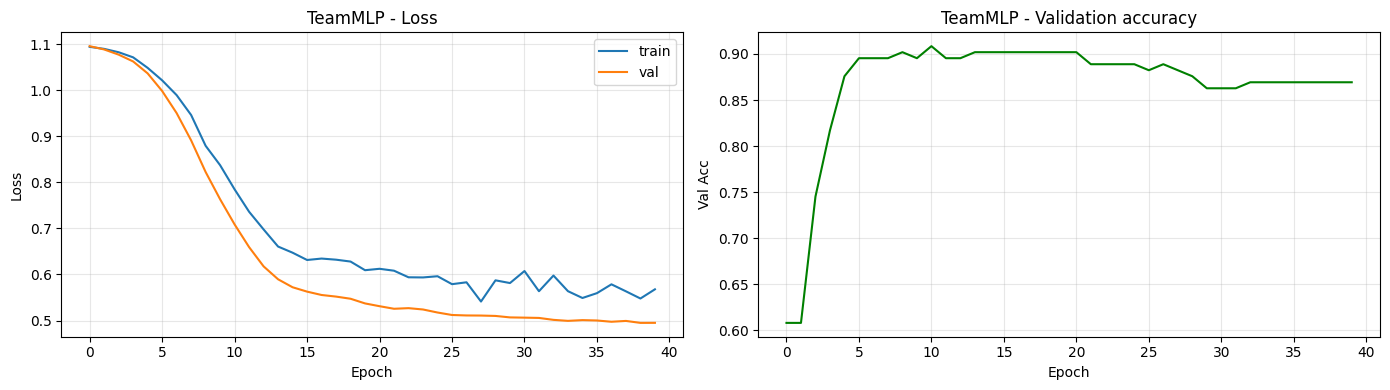

In [21]:
# Train the TeamMLP using the K-means labels
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt

print('Asignando clase refree segun REFEREE_ZONES...')
y_final = []
for i, (x1, y1, x2, y2) in enumerate(all_bboxes):
    cx_bbox = (x1 + x2) / 2
    cy_foot = y2
    is_referee = False
    for rx1, ry1, rx2, ry2 in REFEREE_ZONES:
        if rx1 <= cx_bbox <= rx2 and ry1 <= cy_foot <= ry2:
            is_referee = True
            break
    if is_referee:
        y_final.append(2)
    else:
        y_final.append(int(y_kmeans[i]))

y_final = np.array(y_final, dtype=np.int64)

from collections import Counter
counts = Counter(y_final)
print(f'Distribucion final con refree:')
for cls_id, cls_name in enumerate(TEAM_CLASSES):
    print(f'   {cls_name}: {counts.get(cls_id, 0)} muestras')

X_tensor = torch.tensor(X_colors, dtype=torch.float32)
y_tensor = torch.tensor(y_final, dtype=torch.int64)

full = TensorDataset(X_tensor, y_tensor)
n_train = int(0.8 * len(full))
n_val = len(full) - n_train
train_ds, val_ds = random_split(full, [n_train, n_val],
                                 generator=torch.Generator().manual_seed(42))
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=32)

team_mlp = TeamMLP(input_size=16, num_classes=3).to(DEVICE)
print(f'TeamMLP: {team_mlp.count_parameters():,} parametros')

class_counts = np.bincount(y_final, minlength=3)
class_weights = len(y_final) / (3 * np.maximum(class_counts, 1))
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print(f'Pesos de clase: {class_weights.round(2)}')

criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = optim.Adam(team_mlp.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

EPOCHS = 40
train_losses, val_losses, val_accs = [], [], []
best_val_acc = 0.0

for epoch in range(EPOCHS):
    team_mlp.train()
    train_loss = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out = team_mlp(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(xb)
    train_loss /= len(train_ds)
    train_losses.append(train_loss)

    team_mlp.eval()
    val_loss = 0.0
    correct = 0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out = team_mlp(xb)
            loss = criterion(out, yb)
            val_loss += loss.item() * len(xb)
            pred = out.argmax(1)
            correct += (pred == yb).sum().item()
    val_loss /= len(val_ds)
    val_acc = correct / len(val_ds)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(team_mlp.state_dict(), TEAM_MLP_WEIGHTS)

    scheduler.step()

    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | train_loss={train_loss:.4f} | '
              f'val_loss={val_loss:.4f} | val_acc={val_acc:.3f}')

print(f'\nMejor val_acc: {best_val_acc:.3f}')
print(f'Modelo guardado: {TEAM_MLP_WEIGHTS}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(train_losses, label='train'); axes[0].plot(val_losses, label='val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('TeamMLP - Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(val_accs, color='green')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Acc')
axes[1].set_title('TeamMLP - Validation accuracy'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Section 12 - TeamMLP integration (hybrid mode)
Final override that combines:
- **Homography** + temporal voting (Section 10) runs first
- **TeamMLP** overrides the team assignment when its confidence >= 65%
- **REFEREE_ZONES** still works as a hard override (locked referees are never changed)

This gives us the best of both approaches: geometric stability + real color classification.


In [22]:
# Load the trained TeamMLP and apply it as an override in the pipeline
import types

team_mlp.load_state_dict(torch.load(TEAM_MLP_WEIGHTS, map_location=DEVICE))
team_mlp.eval()

_ORIGINAL_PROCESS_TRACKED = type(pipeline)._process_tracked

def _process_tracked_with_team_mlp_v2(self, frame_bgr, tracked, polygon_dyn, H_dyn):
    H_f, W_f = frame_bgr.shape[:2]
    detections = _ORIGINAL_PROCESS_TRACKED(self, frame_bgr, tracked, polygon_dyn, H_dyn)

    for det in detections:
        tid = det.get('track_id')
        if tid is None: continue

        cx_px  = det['cx'] * W_f
        foot_y = det['foot_y'] * H_f
        in_ref_zone = any(rx1 <= cx_px <= rx2 and ry1 <= foot_y <= ry2
                          for rx1, ry1, rx2, ry2 in REFEREE_ZONES)
        if in_ref_zone:
            det['team'] = 'refree'; det['class_name'] = 'refree'; det['role'] = 'refree'
            if tid in self.track_teams:
                self.track_teams[tid]['locked'] = 'refree'
            continue

        if tid in self.track_teams and self.track_teams[tid].get('locked') == 'refree':
            det['team'] = 'refree'; det['class_name'] = 'refree'; det['role'] = 'refree'
            continue

        bbox = det['box']
        feats = extract_torso_color_features(frame_bgr, bbox)
        if feats is None: continue

        with torch.no_grad():
            x_in = torch.tensor(feats, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            logits = team_mlp(x_in)
            probs = F.softmax(logits, dim=1)[0]
            pred_idx = int(logits.argmax(1).item())
            conf = float(probs[pred_idx].item())
        mlp_team = TEAM_CLASSES[pred_idx]

        # Only override if MLP confidence is high enough and it does not predict refree
        if conf >= 0.65 and mlp_team != 'refree':
            det['team'] = mlp_team
            det['class_name'] = mlp_team
            det['team_conf'] = conf

    return detections

pipeline._process_tracked = types.MethodType(_process_tracked_with_team_mlp_v2, pipeline)
pipeline.reset()
print('TeamMLP integrated into the pipeline')

TeamMLP integrated into the pipeline


In [23]:
# Fix potential K-means label swap: if K-means assigned clusters in reverse order
# we swap the last-layer weights instead of retraining from scratch.

# Check which side of the court each cluster is on.
# Expected: team_1 (France) has smaller cx, team_2 (Japan) has larger cx.

cap = cv2.VideoCapture(VIDEO_PATH)
ret, fr = cap.read(); cap.release()

r = yolo_model.predict(fr, conf=0.40, verbose=False, device=DEVICE)[0]
cx_team1, cx_team2 = [], []
if r.boxes is not None:
    for box in r.boxes:
        x1, y1, x2, y2 = [float(v) for v in box.xyxy[0].cpu().numpy()]
        cx = (x1+x2)/2
        feats = extract_torso_color_features(fr, (x1,y1,x2,y2))
        if feats is None: continue
        with torch.no_grad():
            logits = team_mlp(torch.tensor(feats, dtype=torch.float32, device=DEVICE).unsqueeze(0))
            pred = int(logits.argmax(1).item())
        if pred == 0: cx_team1.append(cx)
        elif pred == 1: cx_team2.append(cx)

cx_t1_med = np.median(cx_team1) if cx_team1 else 0
cx_t2_med = np.median(cx_team2) if cx_team2 else 0
W_f = fr.shape[1]
print(f'Mediana cx team_1: {cx_t1_med:.0f} (lado: {"IZQ" if cx_t1_med < W_f/2 else "DER"})')
print(f'Mediana cx team_2: {cx_t2_med:.0f} (lado: {"IZQ" if cx_t2_med < W_f/2 else "DER"})')

# Decide whether the swap is needed
NEEDS_SWAP = cx_t1_med > cx_t2_med   # team_1 está más a la derecha que team_2 -> mal
print(f'\n{"SWAP NEEDED" if NEEDS_SWAP else "OK - no swap needed"}')

# Apply swap if needed - flip the last layer weights for classes 0 and 1
if NEEDS_SWAP:
    # Swap weights between class 0 (team_1) and class 1 (team_2)
    # Class 2 (refree) stays unchanged
    last_layer = team_mlp.net[-1]   # nn.Linear(16, 3)
    with torch.no_grad():
        # Swap weight rows
        w = last_layer.weight.data.clone()
        last_layer.weight.data[0] = w[1]
        last_layer.weight.data[1] = w[0]
        # Swap bias values
        b = last_layer.bias.data.clone()
        last_layer.bias.data[0] = b[1]
        last_layer.bias.data[1] = b[0]
    print('Swap applied. Saving corrected weights...')
    torch.save(team_mlp.state_dict(), TEAM_MLP_WEIGHTS)
    print(f'Saved: {TEAM_MLP_WEIGHTS}')
else:
    print('No se aplica swap.')

# Reset the pipeline so it uses the updated weights
pipeline.reset()
print('\nPipeline reset. Re-run the frame test cell.')

Mediana cx team_1: 785 (lado: IZQ)
Mediana cx team_2: 1269 (lado: DER)

OK - no swap needed
No se aplica swap.

Pipeline reset. Re-run the frame test cell.


## Section 13 - Quick test on 1 frame
Verifies that the full pipeline works by processing the first frame of the video.


Detecciones:
   # 1: team=team_2   role=refree    pies=(1592, 841)
   # 2: team=team_1   role=attacker  pies=( 256, 811)
   # 3: team=team_1   role=attacker  pies=( 784, 766)
   # 4: team=refree   role=refree    pies=(1088, 950)
   # 5: team=team_1   role=refree    pies=( 943, 760)
   # 6: team=team_1   role=attacker  pies=( 991, 762)
   # 7: team=team_2   role=attacker  pies=(1322, 736)
   # 8: team=refree   role=refree    pies=( 669, 654)
   #10: team=team_2   role=attacker  pies=(1268, 697)
   #11: team=team_2   role=attacker  pies=(1488, 710)
   #13: team=team_1   role=refree    pies=( 821, 797)


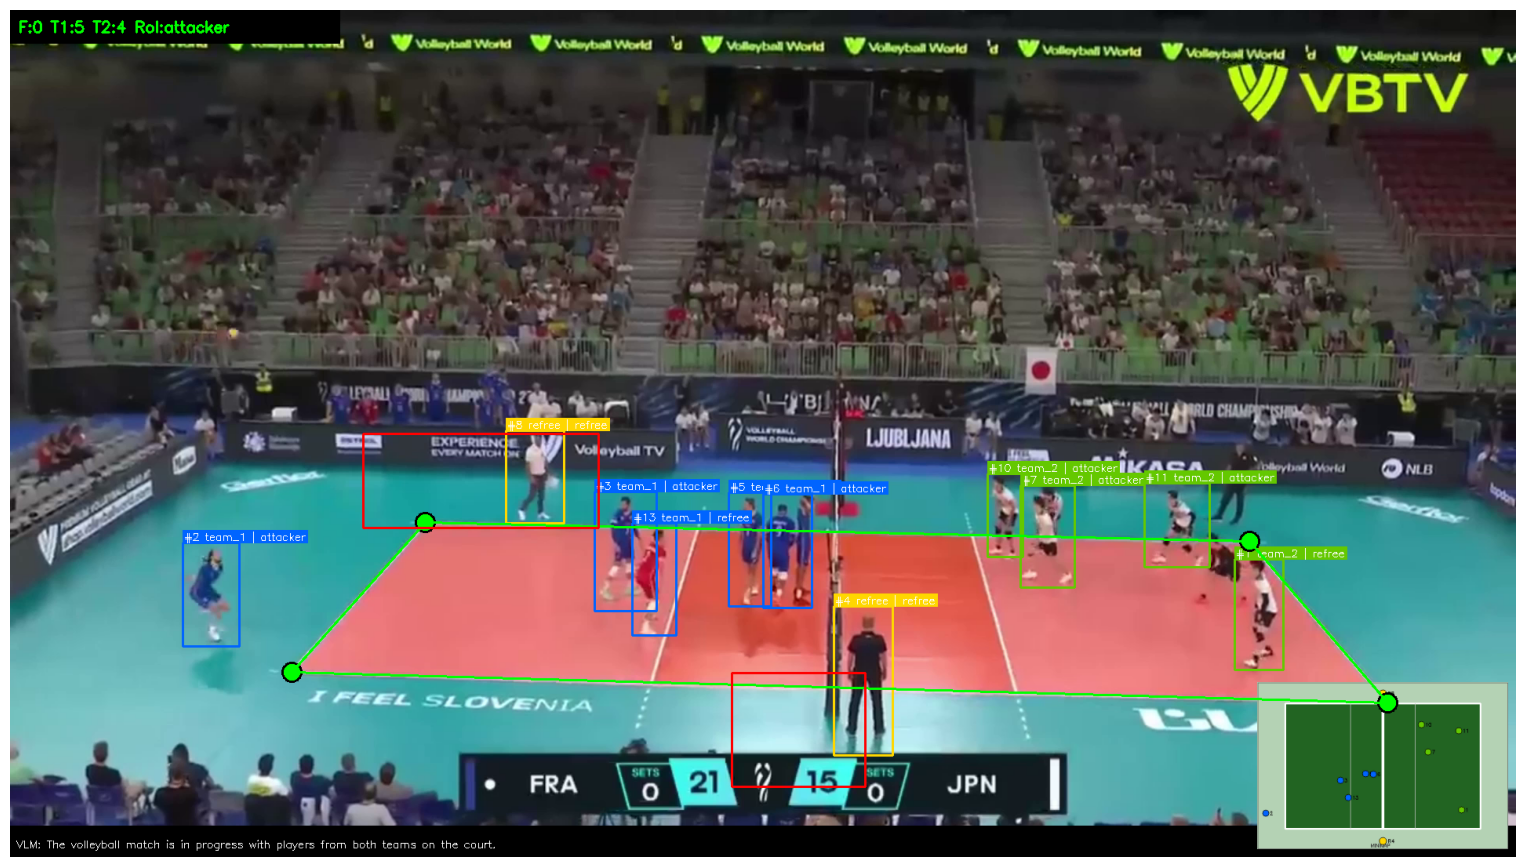

In [24]:

# CELDA 2 - Test visual de 1 frame

cap = cv2.VideoCapture(VIDEO_PATH)
ret, fr = cap.read(); cap.release()
pipeline.reset()
ann, info = pipeline.process_frame(fr)

# Draw the calibrated court trapezoid in green
pts = [(_src[0][0],_src[0][1]), (_src[1][0],_src[1][1]),
       (_src[2][0],_src[2][1]), (_src[3][0],_src[3][1])]
pts = [(int(x), int(y)) for x, y in pts]
for x, y in pts:
    cv2.circle(ann, (x,y), 12, (0,255,0), -1)
    cv2.circle(ann, (x,y), 12, (0,0,0), 2)
for i in range(4):
    cv2.line(ann, pts[i], pts[(i+1)%4], (0,255,0), 2)

# Draw referee zones in red
for x1, y1, x2, y2 in REFEREE_ZONES:
    cv2.rectangle(ann, (x1,y1), (x2,y2), (0,0,255), 2)

# Print detection list to console
print('Detecciones:')
H_f, W_f = fr.shape[:2]
for d in info['detections']:
    cx = d['cx'] * W_f; fy = d['foot_y'] * H_f
    print(f'   #{d["track_id"]:2d}: team={d["team"]:8s} role={d["role"]:9s} pies=({cx:4.0f},{fy:4.0f})')

plt.figure(figsize=(20, 11))
plt.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
plt.axis('off'); plt.show()

In [25]:
# Diagnostic: show TeamMLP predictions for each detected player
import torch.nn.functional as F

cap = cv2.VideoCapture(VIDEO_PATH)
ret, fr = cap.read(); cap.release()

# Detect players in the first frame
r = yolo_model.predict(fr, conf=0.40, verbose=False, device=DEVICE)[0]
print(f'Personas detectadas: {len(r.boxes) if r.boxes is not None else 0}\n')
print(f'{"id":3s} | {"bbox_cx":7s} | {"team_1":7s} | {"team_2":7s} | {"refree":7s} | {"pred":7s}')
print('-' * 70)

if r.boxes is not None:
    for i, box in enumerate(r.boxes):
        x1, y1, x2, y2 = [float(v) for v in box.xyxy[0].cpu().numpy()]
        cx, cy_foot = (x1+x2)/2, y2

        # Check referee zone
        in_ref = any(rx1 <= cx <= rx2 and ry1 <= cy_foot <= ry2
                      for rx1, ry1, rx2, ry2 in REFEREE_ZONES)
        zone_mark = ' [ZONA-REF]' if in_ref else ''

        feats = extract_torso_color_features(fr, (x1,y1,x2,y2))
        if feats is None: continue
        with torch.no_grad():
            x_in = torch.tensor(feats, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            logits = team_mlp(x_in)
            probs = F.softmax(logits, dim=1)[0].cpu().numpy()
        pred = TEAM_CLASSES[int(probs.argmax())]

        # Determine which side of the court the player is on
        cx_norm = cx / fr.shape[1]
        side = 'IZQ' if cx_norm < 0.5 else 'DER'
        print(f'{i:3d} | {int(cx):7d} | {probs[0]:.3f}  | {probs[1]:.3f}  | {probs[2]:.3f}  | '
              f'{pred:7s} [{side}]{zone_mark}')

Personas detectadas: 14

id  | bbox_cx | team_1  | team_2  | refree  | pred   
----------------------------------------------------------------------
  0 |    1592 | 0.157  | 0.489  | 0.354  | team_2  [DER]
  1 |     256 | 0.508  | 0.261  | 0.230  | team_1  [IZQ]
  2 |     784 | 0.724  | 0.137  | 0.140  | team_1  [IZQ]
  3 |    1087 | 0.192  | 0.456  | 0.352  | team_2  [DER] [ZONA-REF]
  4 |     943 | 0.749  | 0.123  | 0.128  | team_1  [IZQ]
  5 |     991 | 0.796  | 0.099  | 0.105  | team_1  [DER]
  6 |    1323 | 0.116  | 0.528  | 0.356  | team_2  [DER]
  7 |     669 | 0.123  | 0.517  | 0.359  | team_2  [IZQ] [ZONA-REF]
  8 |     224 | 0.228  | 0.433  | 0.339  | team_2  [IZQ]
  9 |    1268 | 0.114  | 0.530  | 0.357  | team_2  [DER]
 10 |    1487 | 0.143  | 0.499  | 0.358  | team_2  [DER]
 11 |    1740 | 0.116  | 0.526  | 0.358  | team_2  [DER]
 12 |     821 | 0.159  | 0.480  | 0.361  | team_2  [IZQ]
 13 |     224 | 0.772  | 0.112  | 0.116  | team_1  [IZQ]


## Section 14 - Gradio GUI (unified interface)
GUI with 4 tabs:
- **Image** - upload a frame and run the full pipeline
- **Video** - process N frames and download the annotated result
- **Gemma 4 VQA** - ask the VLM questions about a volleyball image
- **Train CNN** - re-train the CNN classifier with configurable hyperparameters


In [26]:
import gradio as gr

def process_image_gr(image, player_conf, ball_conf, min_h):
    if image is None: return None, 'Sube una imagen.'
    pipeline.reset()
    pipeline.player_conf = float(player_conf)
    pipeline.ball_conf   = float(ball_conf)
    pipeline.min_h       = int(min_h)
    pipeline.ball_tracker.ball_conf = float(ball_conf)
    frame_bgr = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
    ann, info = pipeline.process_frame(frame_bgr)
    n = len(info['detections'])
    teams = Counter(d['team'] for d in info['detections'])
    ball = info['ball']
    summary = (f'Jugadores en campo: {n}\n'
               f'team_1: {teams.get("team_1",0)} | team_2: {teams.get("team_2",0)} | '
               f'refree: {teams.get("refree",0)}\n'
               f'Balon: {"conf="+str(round(ball["conf"],2)) if ball else "no detectado"}\n'
               f'Rol global (CNN): {info["role"]}\n'
               f'Gemma 4: {info["vlm"] or "(pendiente -- corre 60 frames)"}')
    return cv2.cvtColor(ann, cv2.COLOR_BGR2RGB), summary

def process_video_gr(video_file, max_frames, player_conf, ball_conf, min_h):
    if video_file is None: return None, 'Sube un video.'
    pipeline.player_conf = float(player_conf)
    pipeline.ball_conf   = float(ball_conf)
    pipeline.min_h       = int(min_h)
    pipeline.ball_tracker.ball_conf = float(ball_conf)
    out_path = '/content/output_gradio.mp4'
    pipeline.process_video(video_file, out_path, max_frames=int(max_frames))
    return out_path, f'OK {int(max_frames)} frames procesados'

def ask_gemma_gr(image, question):
    if image is None or not question:
        return None, 'Sube imagen y escribe una pregunta.'
    if not vlm_assistant.enabled:
        return None, 'Gemma 4 no esta cargado (USE_GEMMA=False o fallo de carga).'
    try:
        # Run the pipeline first to get detections and annotated image
        pil_img = Image.fromarray(np.array(image))
        answer = vlm_assistant.answer_question_with_context(pil_img, question, pipeline)

        # Return the annotated image so the user can see the pipeline output
        frame_bgr = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
        pipeline.reset()
        annotated, _ = pipeline.process_frame(frame_bgr)
        annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        return annotated_rgb, answer
    except Exception as e:
        return None, f'Error: {e}'

with gr.Blocks(title='Volleyball AI v5 - YOLO + Minimap + Gemma') as demo:
    gr.Markdown('# Volleyball AI v5\nYOLO + Minimap (v3) + CNN + LSTM + MLP + Gemma 4')
    with gr.Tab('Imagen'):
        with gr.Row():
            with gr.Column():
                inp_img = gr.Image(type='pil', label='Frame')
                p_conf = gr.Slider(0.1, 0.9, value=0.35, step=0.05, label='Person conf')
                b_conf = gr.Slider(0.05, 0.9, value=0.15, step=0.05, label='Ball conf')
                m_h    = gr.Slider(20, 200, value=60, step=10, label='Min person height (px)')
                btn_img = gr.Button('Procesar', variant='primary')
            with gr.Column():
                out_img = gr.Image(label='Anotado')
                out_info = gr.Textbox(label='Info', lines=8)
        btn_img.click(process_image_gr, [inp_img, p_conf, b_conf, m_h], [out_img, out_info])
    with gr.Tab('Video'):
        with gr.Row():
            with gr.Column():
                inp_vid = gr.Video(label='Video')
                n_frames = gr.Slider(30, 600, value=120, step=30, label='Max frames')
                pv = gr.Slider(0.1, 0.9, value=0.35, step=0.05, label='Person conf')
                bv = gr.Slider(0.05, 0.9, value=0.15, step=0.05, label='Ball conf')
                mv = gr.Slider(20, 200, value=60, step=10, label='Min person height')
                btn_vid = gr.Button('Procesar', variant='primary')
            with gr.Column():
                out_vid = gr.Video(label='Resultado')
                out_msg = gr.Textbox(label='Info')
        btn_vid.click(process_video_gr, [inp_vid, n_frames, pv, bv, mv], [out_vid, out_msg])
    with gr.Tab('Gemma 4 VQA'):
      gr.Markdown('### El sistema analiza tu imagen y Gemma responde con contexto')
      with gr.Row():
        with gr.Column():
            vqa_img = gr.Image(type='pil', label='Sube una imagen del partido')
            vqa_q = gr.Textbox(label='Pregunta',
                placeholder='Ej: How many players from each team? Who is closer to the net?')
            btn_vqa = gr.Button('Analizar y preguntar', variant='primary')
        with gr.Column():
            vqa_annotated = gr.Image(label='Imagen procesada por el sistema')
            vqa_a = gr.Textbox(label='Respuesta de Gemma 4 (con contexto)', lines=8)
    btn_vqa.click(ask_gemma_gr, [vqa_img, vqa_q], [vqa_annotated, vqa_a])


    with gr.Tab('Entrenar CNN'):
        gr.Markdown("""
        ## Entrenamiento del CNN Clasificador de Roles
        Lanza el reentrenamiento del `VolleyballCNN` con hiperparametros configurables.
        **Requiere** que el dataset `volley_detection-5` este descargado en `/content/`.
        El modelo entrenado se guarda como `best_cnn_classifier.pth`.
        """)
        with gr.Row():
            train_epochs = gr.Slider(5, 50, value=25, step=5, label='Epocas')
            train_lr     = gr.Slider(1e-4, 1e-2, value=1e-3, step=1e-4, label='Learning Rate')
            train_bs     = gr.Slider(8, 64, value=32, step=8, label='Batch Size')
        btn_train = gr.Button('Lanzar entrenamiento CNN', variant='primary')
        train_log = gr.Textbox(label='Log de entrenamiento', lines=20, interactive=False)

        def launch_cnn_training(epochs, lr, batch_size):
            import json as _json
            from pathlib import Path as _Path
            from torch.utils.data import Dataset as _Dataset, DataLoader as _DataLoader
            from torchvision import transforms as _transforms
            import torch.optim as _optim

            dataset_dir = _Path('/content/volley_detection-5')
            crops_dir   = _Path('player_crops')

            # Extract player crops from the dataset if not already done
            if not crops_dir.exists():
                logs = ['Extrayendo crops de jugadores...']
                from collections import defaultdict as _dd
                stats = _dd(int)
                for split in ['train','valid']:
                    ann_f = dataset_dir/split/'_annotations.coco.json'
                    if not ann_f.exists(): continue
                    with open(ann_f) as f: coco=_json.load(f)
                    im={i['id']:i for i in coco['images']}
                    cm={c['id']:c['name'] for c in coco['categories']}
                    for ann in coco['annotations']:
                        cn=cm[ann['category_id']]
                        if cn=='volleyball': continue
                        ip=dataset_dir/split/im[ann['image_id']]['file_name']
                        if not ip.exists(): continue
                        x,y,w,h=[int(v) for v in ann['bbox']]
                        if w<32 or h<32: continue
                        from PIL import Image as _Im
                        crop=_Im.open(ip).convert('RGB').crop((x,y,x+w,y+h))
                        sd=crops_dir/split/cn; sd.mkdir(parents=True,exist_ok=True)
                        crop.save(sd/f"{ann['id']:06d}.jpg"); stats[f'{split}/{cn}']+=1
                logs.append(f'Crops extraidos: {dict(stats)}')
            else:
                logs = ['Crops ya existen, usando los existentes.']

            # Build train/val datasets
            ACTION_CLASSES_SORTED = sorted(['attacker','receiver','refree','server','setter'])
            class _AD(_Dataset):
                def __init__(self, split):
                    self.samples=[]
                    tf_list=[_transforms.Resize((224,224))]
                    if split=='train':
                        tf_list+=[_transforms.RandomHorizontalFlip(),
                                   _transforms.ColorJitter(0.3,0.3,0.2),
                                   _transforms.RandomRotation(10)]
                    tf_list+=[_transforms.ToTensor(),
                               _transforms.Normalize([.485,.456,.406],[.229,.224,.225])]
                    self.tf=_transforms.Compose(tf_list)
                    from PIL import Image as _Im2
                    self._Im=_Im2
                    for i,c in enumerate(ACTION_CLASSES_SORTED):
                        d=crops_dir/split/c
                        if d.exists(): [self.samples.append((p,i)) for p in d.glob('*.jpg')]
                def __len__(self): return len(self.samples)
                def __getitem__(self,i):
                    p,l=self.samples[i]
                    return self.tf(self._Im.open(p).convert('RGB')),l

            tr=_DataLoader(_AD('train'),batch_size=int(batch_size),shuffle=True,num_workers=2)
            vl=_DataLoader(_AD('valid'),batch_size=int(batch_size),num_workers=2)
            if len(tr)==0:
                return 'Error: no se encontraron crops. Descarga el dataset primero.'

            logs.append(f'Train: {len(tr.dataset)} crops | Val: {len(vl.dataset)} crops')

            # Model, optimizer and loss function
            m = VolleyballCNN(num_classes=5).to(DEVICE)
            opt = _optim.AdamW(m.parameters(), lr=float(lr), weight_decay=1e-4)
            sch = _optim.lr_scheduler.CosineAnnealingLR(opt, T_max=int(epochs))
            crit = nn.CrossEntropyLoss()
            best_acc = 0.0
            logs.append(f'Iniciando entrenamiento: {int(epochs)} epocas, lr={float(lr):.4f}, bs={int(batch_size)}')

            for ep in range(int(epochs)):
                m.train(); tl,tc,tt=0,0,0
                for imgs,labs in tr:
                    imgs,labs=imgs.to(DEVICE),labs.to(DEVICE)
                    opt.zero_grad(); out=m(imgs); loss=crit(out,labs)
                    loss.backward(); opt.step()
                    tl+=loss.item(); tc+=out.argmax(1).eq(labs).sum().item(); tt+=labs.size(0)
                sch.step()
                m.eval(); vl_,vc,vt=0,0,0
                with torch.no_grad():
                    for imgs,labs in vl:
                        imgs,labs=imgs.to(DEVICE),labs.to(DEVICE); out=m(imgs)
                        vl_+=crit(out,labs).item(); vc+=out.argmax(1).eq(labs).sum().item(); vt+=labs.size(0)
                ta,va=tc/max(tt,1),vc/max(vt,1)
                if va>best_acc:
                    best_acc=va
                    torch.save(m.state_dict(),'best_cnn_classifier.pth')
                    torch.save(m.state_dict(), CNN_WEIGHTS)
                if (ep+1)%5==0 or ep==0:
                    log=f'Epoca {ep+1:3d}/{int(epochs)} | Loss:{tl/len(tr):.4f} | ValAcc:{va:.3f}'
                    logs.append(log)

            logs.append(f'Completado. Mejor Val Acc: {best_acc:.3f}')
            logs.append('Modelo guardado: best_cnn_classifier.pth')
            # Reload the new weights into the active pipeline
            try:
                cnn_model.load_state_dict(torch.load('best_cnn_classifier.pth', map_location=DEVICE))
                cnn_model.eval()
                logs.append('CNN recargado en el pipeline.')
            except Exception as e:
                logs.append(f'Aviso al recargar: {e}')
            return '\n'.join(logs)

        btn_train.click(launch_cnn_training, [train_epochs, train_lr, train_bs], [train_log])

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5583cb8a6a3c5967ed.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [27]:
# Diagnostic: show CNN role predictions for each detected player
import torch.nn.functional as F

cap = cv2.VideoCapture(VIDEO_PATH)
ret, fr = cap.read(); cap.release()

# Detect players with the custom YOLO model
r = yolo_model.predict(fr, conf=0.40, verbose=False, device=DEVICE)[0]
print(f'Personas detectadas: {len(r.boxes) if r.boxes is not None else 0}')
print(f'CNN clases: {ACTION_CLASSES}')
print(f'IDX_TO_ACTION: {IDX_TO_ACTION}\n')
print(f'{"id":3s} | {"cx":5s} | {"side":4s} | predicciones del CNN para cada clase')
print('-' * 90)

if r.boxes is not None:
    for i, box in enumerate(r.boxes):
        x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].cpu().numpy()]
        cx = (x1 + x2) / 2
        side = 'IZQ' if cx < fr.shape[1]/2 else 'DER'

        # Crop the player bounding box
        crop = fr[y1:y2, x1:x2]
        if crop.size == 0: continue

        # Run the CNN on the crop
        pil_crop = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        cnn_model.eval()
        with torch.no_grad():
            x_in = pipeline.cnn_tf(pil_crop).unsqueeze(0).to(DEVICE)
            logits = cnn_model(x_in)
            probs = F.softmax(logits, dim=1)[0].cpu().numpy()
        pred_idx = int(probs.argmax())
        pred_class = IDX_TO_ACTION[pred_idx]

        probs_str = ' '.join(f'{IDX_TO_ACTION[k]}:{probs[k]:.2f}' for k in range(len(probs)))
        print(f'{i:3d} | {int(cx):5d} | {side:4s} | {probs_str}  ->  {pred_class}')

Personas detectadas: 14
CNN clases: ['attacker', 'receiver', 'refree', 'server', 'setter']
IDX_TO_ACTION: {0: 'attacker', 1: 'receiver', 2: 'refree', 3: 'server', 4: 'setter'}

id  | cx    | side | predicciones del CNN para cada clase
------------------------------------------------------------------------------------------
  0 |  1592 | DER  | attacker:0.01 receiver:0.00 refree:0.99 server:0.00 setter:0.00  ->  refree
  1 |   256 | IZQ  | attacker:1.00 receiver:0.00 refree:0.00 server:0.00 setter:0.00  ->  attacker
  2 |   784 | IZQ  | attacker:0.91 receiver:0.00 refree:0.09 server:0.00 setter:0.00  ->  attacker
  3 |  1087 | DER  | attacker:1.00 receiver:0.00 refree:0.00 server:0.00 setter:0.00  ->  attacker
  4 |   943 | IZQ  | attacker:0.00 receiver:0.00 refree:1.00 server:0.00 setter:0.00  ->  refree
  5 |   991 | DER  | attacker:0.77 receiver:0.00 refree:0.23 server:0.00 setter:0.00  ->  attacker
  6 |  1322 | DER  | attacker:1.00 receiver:0.00 refree:0.00 server:0.00 setter:0.00

---
## Section 15 - Model Evaluation & Metrics
Performance evaluation of all trained models: YOLO player detector, YOLO ball detector, and TeamMLP.
Requires the training dataset zip files uploaded to `/content/`.
---


### Step 1 - Extract datasets
Upload `player.yolov8.zip` and `volleyball-ball-a-jpn.yolov8.zip` to Colab, then run this cell.


In [29]:
import zipfile, os

os.makedirs('/content/dataset_personas', exist_ok=True)
os.makedirs('/content/dataset_balon', exist_ok=True)

with zipfile.ZipFile('/content/player.yolov8.zip', 'r') as z:
    z.extractall('/content/dataset_personas/')

with zipfile.ZipFile('/content/volleyball-ball-a-jpn.yolov8.zip', 'r') as z:
    z.extractall('/content/dataset_balon/')

print("Datasets extracted OK")

Datasets extracted OK


### Step 2 - YOLO player detector: mAP, Precision, Recall, F1


In [30]:
import yaml

# Read and fix the data.yaml paths
yaml_path = '/content/dataset_personas/data.yaml'
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

print("data.yaml loaded:", data)

# Forzar que train y val apunten a la carpeta train
data['train'] = '/content/dataset_personas/train/images'
data['val']   = '/content/dataset_personas/train/images'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print("data.yaml paths corrected")

# Ahora evaluar
print("=== YOLO PLAYER DETECTOR ===")
model_personas = YOLO('/content/volleyball_persons_best.pt')
metrics = model_personas.val(data=yaml_path, split='val')

print(f"mAP@50:      {metrics.box.map50:.3f}")
print(f"mAP@50-95:   {metrics.box.map:.3f}")
print(f"Precision:   {metrics.box.mp:.3f}")
print(f"Recall:      {metrics.box.mr:.3f}")
f1 = 2 * metrics.box.mp * metrics.box.mr / (metrics.box.mp + metrics.box.mr + 1e-8)
print(f"F1 Score:    {f1:.3f}")

data.yaml loaded: {'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 1, 'names': ['player'], 'roboflow': {'workspace': 'carloss-workspace-u4ffn', 'project': 'carloss-workspace-u4ffn', 'version': 'dataset', 'license': 'Private', 'url': 'https://app.roboflow.com/carloss-workspace-u4ffn/carloss-workspace-u4ffn/dataset'}}
data.yaml paths corrected
=== YOLO PLAYER DETECTOR ===
Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2262.8±794.8 MB/s, size: 77.4 KB)
val: Scanning /content/dataset_personas/train/labels... 50 images, 5 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 50/50 1.5Kit/s 0.0s
val: New cache created: /content/dataset_personas/train/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.3it/s 3.1s
  

### Step 3 - YOLO ball detector: mAP, Precision, Recall, F1


In [31]:
import yaml
from ultralytics import YOLO

yaml_path_b = '/content/dataset_balon/data.yaml'
with open(yaml_path_b, 'r') as f:
    data_b = yaml.safe_load(f)

data_b['train'] = '/content/dataset_balon/train/images'
data_b['val']   = '/content/dataset_balon/train/images'

with open(yaml_path_b, 'w') as f:
    yaml.dump(data_b, f)

print("=== YOLO BALL DETECTOR ===")
model_balon = YOLO('/content/volleyball_ball_best.pt')
metrics_b = model_balon.val(data=yaml_path_b, split='val')

print(f"mAP@50:      {metrics_b.box.map50:.3f}")
print(f"mAP@50-95:   {metrics_b.box.map:.3f}")
print(f"Precision:   {metrics_b.box.mp:.3f}")
print(f"Recall:      {metrics_b.box.mr:.3f}")
f1_b = 2 * metrics_b.box.mp * metrics_b.box.mr / (metrics_b.box.mp + metrics_b.box.mr + 1e-8)
print(f"F1 Score:    {f1_b:.3f}")

=== YOLO BALL DETECTOR ===
Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3625.7±997.7 MB/s, size: 449.7 KB)
val: Scanning /content/dataset_balon/train/labels... 32 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 32/32 1.4Kit/s 0.0s
val: New cache created: /content/dataset_balon/train/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.0it/s 1.0s
                   all         32         34      0.828      0.735      0.735      0.362
Speed: 1.9ms preprocess, 3.8ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /content/runs/detect/val-2
mAP@50:      0.735
mAP@50-95:   0.362
Precision:   0.828
Recall:      0.735
F1 Score:    0.779


### Step 4 - TeamMLP: confusion matrix and classification report


=== TeamMLP Evaluation ===
              precision    recall  f1-score   support

      team_1       0.01      0.02      0.01        47
      team_2       0.00      0.00      0.00        93
      refree       0.00      0.00      0.00        13

    accuracy                           0.01       153
   macro avg       0.00      0.01      0.00       153
weighted avg       0.00      0.01      0.00       153



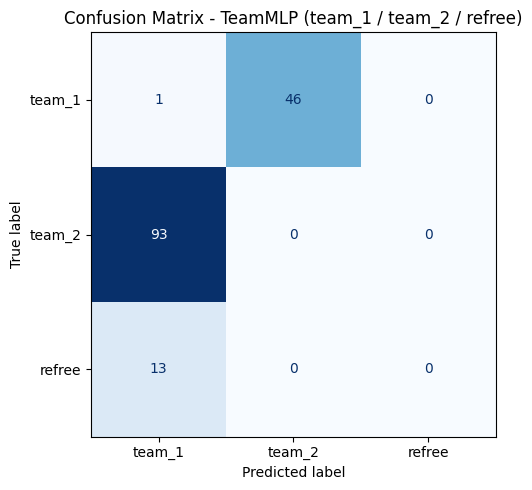

In [32]:
# TeamMLP evaluation
# Reload the saved weights (post-swap) before evaluating
team_mlp.load_state_dict(torch.load('best_team_mlp.pt', map_location=DEVICE))
team_mlp.eval()

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

print('=== TeamMLP Evaluation ===')
all_preds, all_labels = [], []

with torch.no_grad():
    for xb, yb in val_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        out = team_mlp(xb)
        preds = out.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

# After the swap, class 0 and class 1 predictions are flipped relative to
# the original K-means labels stored in val_dl.
# We invert predictions 0<->1 to match the corrected label convention.
all_preds_corrected = []
for p in all_preds:
    if p == 0: all_preds_corrected.append(1)
    elif p == 1: all_preds_corrected.append(0)
    else: all_preds_corrected.append(p)  # refree stays

print(classification_report(
    all_labels, all_preds_corrected,
    target_names=TEAM_CLASSES, zero_division=0))

cm = confusion_matrix(all_labels, all_preds_corrected)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TEAM_CLASSES)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix - TeamMLP (team_1 / team_2 / refree)')
plt.tight_layout()
plt.show()


### Step 5 - CNN role classifier: training curves and evaluation


In [33]:
# CNN training curves and per-class evaluation
# Requires the CNN to have been trained and 'history' dict available.
# If you loaded weights from file (Quick Load), skip to the evaluation block below.

# -- Training curves (only if trained in this session) --
if 'cnn_history' in dir():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(cnn_history['train_loss'], label='Train', color='#2196F3')
    ax1.plot(cnn_history['val_loss'],   label='Val',   color='#F44336')
    ax1.set_title('VolleyballCNN - Loss per epoch')
    ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(cnn_history['train_acc'], label='Train', color='#4CAF50')
    ax2.plot(cnn_history['val_acc'],   label='Val',   color='#FF9800')
    ax2.set_title('VolleyballCNN - Accuracy per epoch')
    ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)
    plt.suptitle('VolleyballCNN Training History', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print('CNN trained externally - curves not available here.')
    print('See train_cnn_classifier.ipynb for full training history.')
    print('Best val accuracy: 93.6% (25 epochs, AdamW lr=1e-3)')

# -- Per-class evaluation on validation crops --
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from pathlib import Path

crops_dir = Path('player_crops')
if crops_dir.exists():
    class _ValDS(torch.utils.data.Dataset):
        def __init__(self):
            self.samples = []
            self.tf = transforms.Compose([
                transforms.Resize((224,224)), transforms.ToTensor(),
                transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
            for i, c in enumerate(sorted(ACTION_CLASSES)):
                d = crops_dir/'valid'/c
                if d.exists(): [self.samples.append((p,i)) for p in d.glob('*.jpg')]
        def __len__(self): return len(self.samples)
        def __getitem__(self, i):
            p, l = self.samples[i]
            return self.tf(Image.open(p).convert('RGB')), l

    val_cnn = torch.utils.data.DataLoader(_ValDS(), batch_size=32, num_workers=2)
    preds_all, labels_all = [], []
    cnn_model.eval()
    with torch.no_grad():
        for imgs, labs in val_cnn:
            imgs = imgs.to(DEVICE)
            preds_all.extend(cnn_model(imgs).argmax(1).cpu().numpy())
            labels_all.extend(labs.numpy())
    class_names = sorted(ACTION_CLASSES)
    print(classification_report(labels_all, preds_all, target_names=class_names))
    cm = confusion_matrix(labels_all, preds_all)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title('Confusion Matrix - VolleyballCNN (role classifier)')
    plt.tight_layout(); plt.show()
else:
    print('player_crops/ not found. Run Section 11 (K-means) first to extract crops.')


CNN trained externally - curves not available here.
See train_cnn_classifier.ipynb for full training history.
Best val accuracy: 93.6% (25 epochs, AdamW lr=1e-3)
player_crops/ not found. Run Section 11 (K-means) first to extract crops.
